In [9]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
def comment_size(size):
    if size < 50:
        return "short"
    elif size < 200:
        return "medium"
    else:
        return "long"
    

def clean_data(df):
    
    cols_to_keep = ['comment', 'rating','extra','original','source']  
    df = df[cols_to_keep] 
    # remove rows with missing comments
    df = df[df['comment'].notna()]
    # calculate the length of each comment
    df['comment_len'] = df['comment'].apply(lambda x: len(x))
    # remove comments with less than 10 characters
    df = df[df['comment_len'] > 10]
    # size of comment [short, medium, long]
    df['size'] = df['comment_len'].apply(comment_size)
    
    return df  
    


In [13]:
folder = "data/reviews"
files = os.listdir(folder)
df = pd.concat([pd.read_csv(f"{folder}/{f}") for f in files])


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2726 entries, 0 to 100
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2726 non-null   int64 
 1   username    2726 non-null   object
 2   rating      2726 non-null   int64 
 3   date        2726 non-null   object
 4   likes       2726 non-null   int64 
 5   comment     1330 non-null   object
 6   extra       321 non-null    object
 7   original    1330 non-null   object
 8   source      2726 non-null   object
dtypes: int64(3), object(6)
memory usage: 213.0+ KB


In [15]:
df.head()

,Unnamed: 0,username,rating,date,likes,comment,extra,original,source
0,0,Do you Know,3,a day ago,0,NaN,",Service:4…",NaN,Friedom
1,1,Zahda Ilham,5,a month ago,0,NaN,",Service:5…",NaN,Friedom
2,2,Nesreen,3,2 months ago,0,Not salty enough,",Price per person:DZD 2,000–3,000,Food:2,Servi...",Not salty enough,Friedom
3,3,Ayoub Br,4,2 months ago,0,NaN,NaN,NaN,Friedom
4,4,Sofiane Yaici,5,3 months ago,0,NaN,",Service:5…",NaN,Friedom


In [ ]:
df = clean_data(df)
df.head()

,comment,rating,extra,original,source,comment_len,size
2,Not salty enough,3,",Price per person:DZD 2,000–3,000,Food:2,Servi...",Not salty enough,Friedom,16,short
9,Overall good chicken and fries,4,",Service:Dine in,Food:4,Service:3,Atmosphere:3",Overall good chicken and fries,Friedom,30,short
10,Over rated\nTiles that are sticky to each othe...,1,",Food:3,Service:2,Atmosphere:1",Over rated\nطوابل لازقين فبعضاهم و مزيتتين ميش...,Friedom,145,medium
11,Food took +30 minutes to come.,2,",Service:Dine in,Meal type:Lunch,Price per per...",Food took +30 minutes to come.,Friedom,30,short
12,"●●●●Food : ● the buns are so soggy ""DEAD"" like...",2,",Service:Dine in,Meal type:Dinner,Price per pe...","●●●●Food : ● the buns are so soggy ""DEAD"" like...",Friedom,701,long


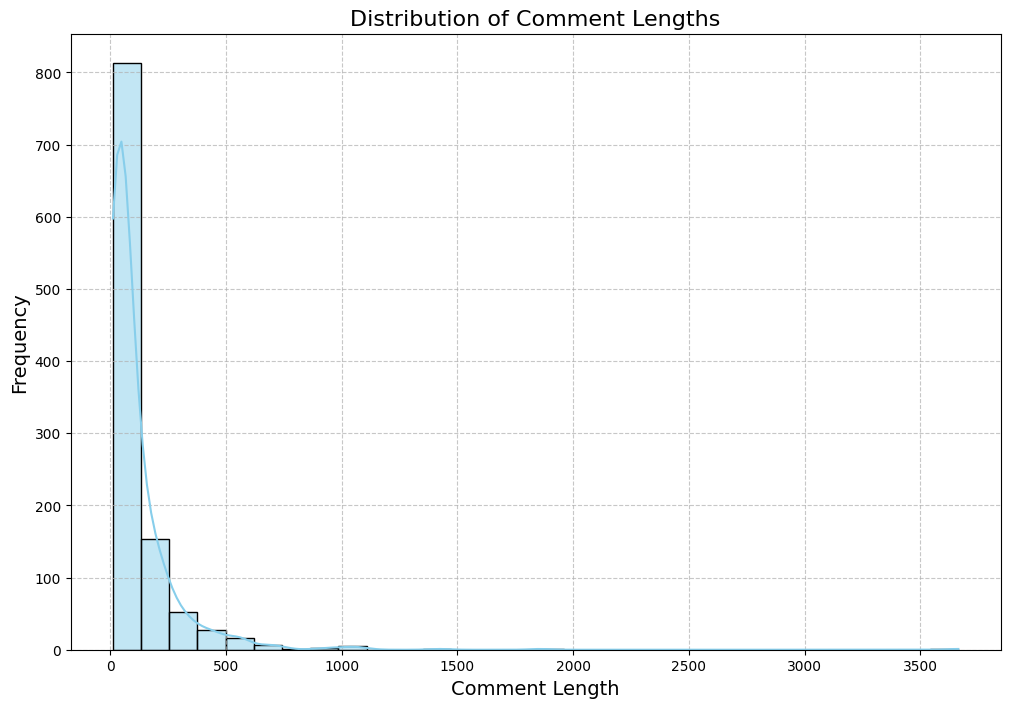

In [5]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='comment_len', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Comment Lengths', fontsize=16)
plt.xlabel('Comment Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_113441/2890468081.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='size', palette='viridis', shrink=0.8)


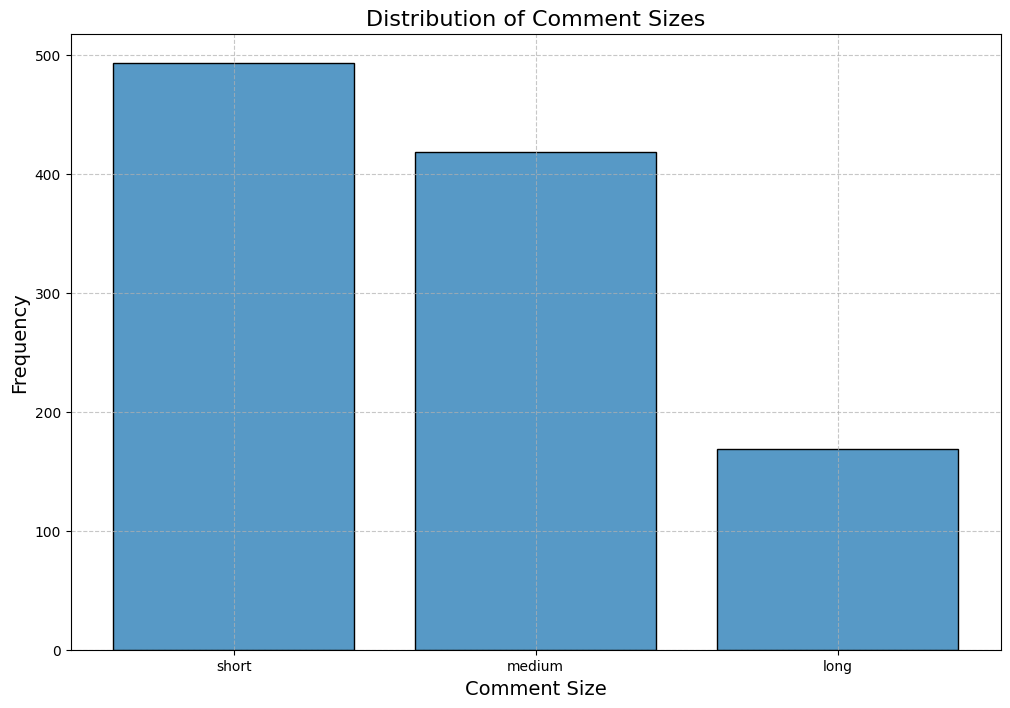

In [8]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='size', palette='viridis', shrink=0.8)
plt.title('Distribution of Comment Sizes', fontsize=16)
plt.xlabel('Comment Size', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [73]:
df[df['size'] == "long"].iloc[0]['comment']

'●●●●Food : ● the buns are so soggy "DEAD" like they can\'t even stand like the one  in the menu\n●the chicken is Half cooked and with no taste\n●The sauce tastes like dust like i,m putting my grandfathers ashes😐 on my burger\n●●●●Service : tooooo sloooow if it was in a turtle race the turtle wins EASILY,  the crew tht was delivering food to the table are so rude and cursing like " are u kissing ur mom with tht mouth" SHEEESH some of them yelled 216 in French but in Arabic said 219.  like u nailed it 👍\nBad Management of food\n●●●●Atmosphere : u need ventilation like U NEED IT VERY VERY MUCH , The oil was the Atmosphere like replacement of O2 tht we breath . Prices are higher then wht we were served'

In [70]:
df.shape

(1080, 7)

In [76]:
%pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 KB 1.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [77]:
df.to_excel("data/reviews.xlsx", index=False)